# Caso 7 — Variação dos Parâmetros do BM25

Avaliamos as 9 combinações de `k1 ∈ {0,5; 1,2; 2,0}` e `b ∈ {0; 0,75; 1}`,
usando MAP e NDCG@10 (métrica graduada adicional) como critérios de
comparação — todas as demais condições (pré-processamento, coleção,
consultas, qrels) permanecem fixas.


In [ ]:
from pathlib import Path
import sys
project_root = Path.cwd()
if not (project_root / "src").is_dir() and (project_root.parent / "src").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from src.cranfield_data import load_cranfield
from src.pre_processing import load_preprocessed
from src.bm25 import BM25
from src.metrics import evaluate_model

df_docs, df_queries, df_qrels = load_cranfield()
preprocessed = load_preprocessed(project_root / "data" / "processed" / "preprocessed_cranfield.pkl")
doc_tokens = preprocessed["stopwords_stemming"]["docs"]
query_tokens_list = preprocessed["stopwords_stemming"]["queries"]
doc_ids = df_docs["doc_id"].tolist()
query_ids = df_queries["query_id"].tolist()
doc_title = dict(zip(df_docs.doc_id, df_docs.title.str.replace("\n", " ")))
doc_len = dict(zip(doc_ids, [len(t) for t in doc_tokens]))

## Grade de parâmetros

In [ ]:
# Grade de parâmetros exigida: k1 em {0.5, 1.2, 2.0}, b em {0, 0.75, 1}
# (9 combinações). O índice invertido é construído uma única vez; apenas
# k1/b mudam entre as iterações (set_params não reconstrói o índice).
K1_VALUES = [0.5, 1.2, 2.0]
B_VALUES = [0, 0.75, 1]
K = 10

bm25 = BM25(doc_tokens)
grid_rows = []
rankings_by_param = {}

for k1 in K1_VALUES:
    for b in B_VALUES:
        bm25.set_params(k1=k1, b=b)
        rankings = {qid: [doc_ids[i] for i, _ in bm25.rank(qtoks)]
                    for qid, qtoks in zip(query_ids, query_tokens_list)}
        rankings_by_param[(k1, b)] = rankings
        ev = evaluate_model(rankings, df_qrels, k=K)
        grid_rows.append({
            "k1": k1, "b": b,
            "MAP": ev["AP"].mean(),
            "P@10": ev["precision@10"].mean(),
            "NDCG@10": ev["ndcg@10"].mean(),
        })

df_grid = pd.DataFrame(grid_rows)
display(df_grid.round(4))

,k1,b,MAP,P@10,NDCG@10
0,0.5,0.00,0.2532,0.1942,0.2917
1,0.5,0.75,0.2761,0.2067,0.3171
2,0.5,1.00,0.2768,0.2044,0.3189
3,1.2,0.00,0.2691,0.2009,0.3046
4,1.2,0.75,0.2956,0.2169,0.3350
5,1.2,1.00,0.2959,0.2178,0.3353
6,2.0,0.00,0.2737,0.2031,0.3120
7,2.0,0.75,0.3024,0.2253,0.3476
8,2.0,1.00,0.2949,0.2231,0.3348


## Visualização

Os dois mapas de calor abaixo mostram o mesmo padrão qualitativo em MAP e
NDCG@10.


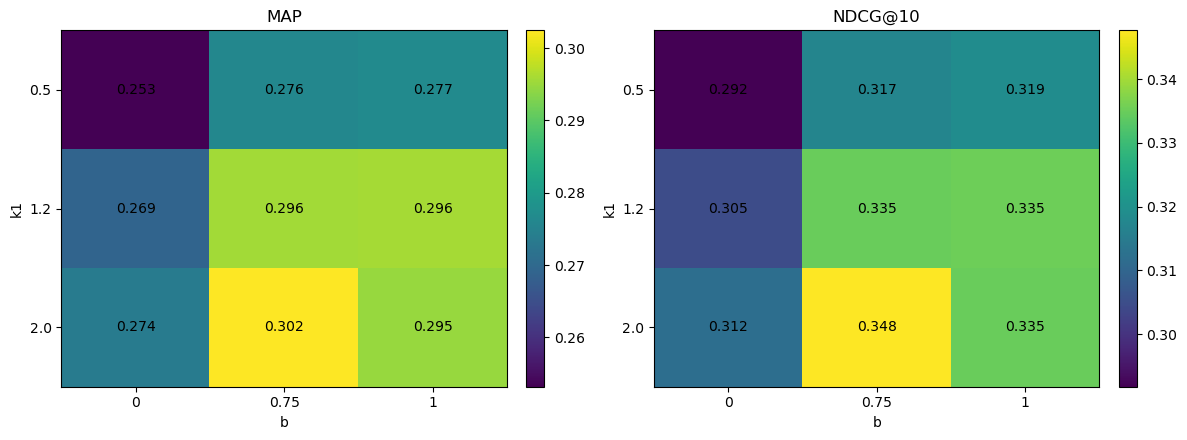

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, metric in zip(axes, ["MAP", "NDCG@10"]):
    pivot = df_grid.pivot(index="k1", columns="b", values=metric)
    im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(B_VALUES))); ax.set_xticklabels(B_VALUES)
    ax.set_yticks(range(len(K1_VALUES))); ax.set_yticklabels(K1_VALUES)
    ax.set_xlabel("b"); ax.set_ylabel("k1"); ax.set_title(metric)
    for i in range(len(K1_VALUES)):
        for j in range(len(B_VALUES)):
            ax.text(j, i, f"{pivot.values[i,j]:.3f}", ha="center", va="center",
                    color="white" if pivot.values[i,j] < pivot.values.max()*0.75 else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Efeito de k1 e de b

**Efeito de `b`**: para os três valores de k1 testados, `b=0` (sem
normalização pelo comprimento do documento) é **sempre a pior
configuração** — MAP fica entre 0,253–0,274, contra 0,276–0,302 com
`b=0,75` ou `b=1`. Isso confirma que, na coleção Cranfield, documentos
mais longos tendem a acumular termos e frequências por puro tamanho, e
não corrigir esse efeito prejudica o ranking. A diferença entre `b=0,75`
e `b=1` é pequena e não-monotônica: com k1=0,5 e k1=1,2, `b=1` é
ligeiramente melhor que `b=0,75` (0,2768 vs 0,2761; 0,2959 vs 0,2956);
já com k1=2,0 a diferença se inverte e cresce (`b=0,75`=0,3024 vs
`b=1`=0,2949) — sugerindo que, uma vez que a normalização por
comprimento está "ligada" em alguma magnitude razoável, o ganho marginal
de intensificá-la ainda mais é pequeno e depende da interação com k1
(como o estudo de caso abaixo ilustra, `b=1` também pode trazer para o
Top-10 documentos curtos que só por isso concentram termos da consulta).

**Efeito de `k1`**: para `b=0` e `b=0,75`, aumentar k1 de 0,5 para 2,0
**sempre** melhora o MAP (por exemplo, com b=0,75: 0,276 -> 0,296 ->
0,302), embora com retornos decrescentes. Já com `b=1` o padrão deixa de
ser monotônico: o MAP sobe de k1=0,5 (0,2768) para k1=1,2 (0,2959), mas
cai levemente em k1=2,0 (0,2949) — indicando que, quando a normalização
por comprimento já está no máximo, aumentar ainda mais a saturação de
frequência de termo (k1 alto) deixa de trazer ganho e pode até
prejudicar ligeiramente.

**Melhor combinação testada**: `k1=2,0, b=0,75` (MAP=0,3024), acima da
configuração "padrão" usada nos casos anteriores (`k1=1,2, b=0,75`,
MAP=0,2956).


## Uma consulta onde `b` muda o ranking perceptivelmente

Para encontrar um exemplo concreto, comparamos o Top-10 obtido com
`k1=1,2` fixo e `b=0` contra `b=1`, em todas as 225 consultas, escolhendo
a de menor sobreposição entre os dois Top-10: a consulta 179 (sobre
teoria de escoamentos quase-cônicos em regime supersônico), com apenas
2 dos 10 documentos em comum entre as duas configurações.

- **`b=0`**: o topo é dominado por documentos **mais longos** (doc 1280
  com 146 tokens, doc 704 com 195 tokens). O único documento relevante
  julgado (doc 680, grau 3, apenas 79 tokens) fica na 3ª posição, atrás
  de dois documentos não julgados que só têm mais termos por serem mais
  extensos.
- **`b=0,75`**: a normalização por comprimento faz o doc 680 (curto e
  relevante) subir ao 1º lugar, e vários outros documentos curtos entram
  no Top-10 (doc 224 com 42 tokens, doc 930 com 81, doc 428 com 90) —
  mas nenhum deles é relevante; o Top-10 continua com apenas 1
  documento relevante.
- **`b=1`**: com a normalização levada ao máximo, o doc 680 se mantém em
  1º lugar e um segundo documento relevante, doc 682 (grau 3, 99
  tokens), consegue entrar na 10ª posição — deslocando um documento não
  julgado. O Top-10 passa a ter 2 documentos relevantes.

Nesta consulta específica, portanto, o efeito de `b` é monotônico:
mais normalização por comprimento ajuda a promover os dois documentos
relevantes (ambos curtos) e prejudica documentos longos e não julgados
que só apareciam no topo por acumularem mais termos — o oposto do que
se observa na média da grade, onde `b=0,75` supera `b=1` para k1=2,0.
Isso reforça que o efeito de `b` é específico de cada consulta: seu
valor ótimo depende de quão correlacionados estão, para aquela consulta,
"documento relevante" e "documento longo" na coleção.


In [ ]:
# Consulta sensível a b: comparamos, entre todas as 225 consultas, o
# overlap do Top-10 obtido com b=0 vs. b=1 (k1=1.2 fixo), e escolhemos a
# consulta com MENOR overlap — ou seja, onde variar b muda mais o ranking.
k1_fixo = 1.2
r_b0 = rankings_by_param[(k1_fixo, 0)]
r_b1 = rankings_by_param[(k1_fixo, 1)]

overlaps = [(qid, len(set(r_b0[qid][:K]) & set(r_b1[qid][:K]))) for qid in query_ids]
overlaps.sort(key=lambda x: x[1])
qid_sensivel = overlaps[0][0]
print(f"Consulta escolhida: {qid_sensivel} (overlap de Top-10 entre b=0 e b=1: "
      f"{overlaps[0][1]}/10)")
print(f"Texto: {df_queries.set_index('query_id').loc[qid_sensivel, 'text']}")
print(f"Tokens: {query_tokens_list[query_ids.index(qid_sensivel)]}")

grades = dict(zip(df_qrels[df_qrels.query_id == qid_sensivel].doc_id,
                   df_qrels[df_qrels.query_id == qid_sensivel].relevance))

for b in B_VALUES:
    ranking = rankings_by_param[(k1_fixo, b)][qid_sensivel][:10]
    n_rel = sum(1 for d in ranking if grades.get(d, -1) >= 1)
    print(f"\n-- Top-10 com k1={k1_fixo}, b={b} (relevantes no Top-10: {n_rel}) --")
    for rank, did in enumerate(ranking, start=1):
        grade = grades.get(did, "não julgado")
        print(f"  {rank:2d}. doc {did} (len={doc_len[did]:3d} tokens, grau={grade}) "
              f"{doc_title[did][:55]}")

Consulta escolhida: 179 (overlap de Top-10 entre b=0 e b=1: 2/10)
Texto: has a theory of quasi-conical flows been developed, in supersonic
linearised theory, for which the upwash distribution on the lifting
surface, apart from being a homogeneous function in the
co-ordinate, is permitted to have a quite general functional form .
Tokens: ['theori', 'flow', 'develop', 'superson', 'linearis', 'theori', 'upwash', 'distribut', 'lift', 'surfac', 'apart', 'homogen', 'function', 'permit', 'quit', 'gener', 'function', 'form']

-- Top-10 com k1=1.2, b=0 (relevantes no Top-10: 1) --
   1. doc 1280 (len=146 tokens, grau=não julgado) wings with minimum drag due to lift in supersonic flow 
   2. doc 704 (len=195 tokens, grau=não julgado) a systematic kernel function procedure for determining 
   3. doc 680 (len= 79 tokens, grau=3) generalized conical flow fields in supersonic wing theo
   4. doc 433 (len=233 tokens, grau=não julgado) application of two dimensional vortex theory to the pre
   5. doc 